In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Plot settings
plt.style.use("ggplot")

In [3]:
airports = pd.read_csv("../../data/raw/airports/airports.csv")

In [4]:
airports.head()

,id,ident,type,name,latitude_deg,longitude_deg,elevation_ft,continent,iso_country,iso_region,municipality,scheduled_service,icao_code,iata_code,gps_code,local_code,home_link,wikipedia_link,keywords
0,6523,00A,heliport,Total RF Heliport,40.070985,-74.933689,11.0,NaN,US,US-PA,Bensalem,no,NaN,NaN,K00A,00A,https://www.penndot.pa.gov/TravelInPA/airports...,NaN,NaN
1,323361,00AA,small_airport,Aero B Ranch Airport,38.704022,-101.473911,3435.0,NaN,US,US-KS,Leoti,no,NaN,NaN,00AA,00AA,NaN,NaN,NaN
2,6524,00AK,small_airport,Lowell Field,59.947733,-151.692524,450.0,NaN,US,US-AK,Anchor Point,no,NaN,NaN,00AK,00AK,NaN,NaN,NaN
3,6525,00AL,small_airport,Epps Airpark,34.864799,-86.770302,820.0,NaN,US,US-AL,Harvest,no,NaN,NaN,00AL,00AL,NaN,NaN,NaN
4,506791,00AN,small_airport,Katmai Lodge Airport,59.093287,-156.456699,80.0,NaN,US,US-AK,King Salmon,no,NaN,NaN,00AN,00AN,NaN,NaN,NaN


In [5]:
print("Rows :", airports.shape[0])
print("Columns :", airports.shape[1])

Rows : 85670
Columns : 19


In [6]:
airports.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85670 entries, 0 to 85669
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 85670 non-null  int64  
 1   ident              85670 non-null  object 
 2   type               85670 non-null  object 
 3   name               85670 non-null  object 
 4   latitude_deg       85670 non-null  float64
 5   longitude_deg      85670 non-null  float64
 6   elevation_ft       70809 non-null  float64
 7   continent          46021 non-null  object 
 8   iso_country        85367 non-null  object 
 9   iso_region         85670 non-null  object 
 10  municipality       80964 non-null  object 
 11  scheduled_service  85670 non-null  object 
 12  icao_code          10219 non-null  object 
 13  iata_code          9056 non-null   object 
 14  gps_code           44336 non-null  object 
 15  local_code         35951 non-null  object 
 16  home_link          473

In [8]:
missing = airports.isnull().sum()

missing_percentage = (
    airports.isnull().mean()*100
)

missing_df = pd.DataFrame({
    "Missing Values": missing,
    "Percentage": missing_percentage
})

missing_df.sort_values(
    by="Percentage",
)

,Missing Values,Percentage
id,0,0.000000
ident,0,0.000000
type,0,0.000000
name,0,0.000000
latitude_deg,0,0.000000
longitude_deg,0,0.000000
scheduled_service,0,0.000000
iso_region,0,0.000000
iso_country,303,0.353683
municipality,4706,5.493171


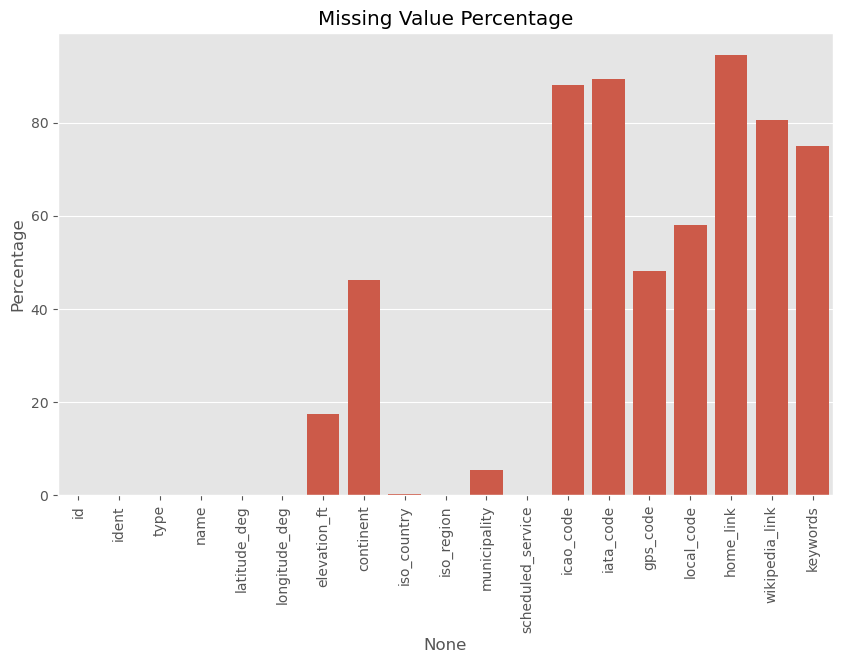

In [9]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=missing_df.index,
    y=missing_df["Percentage"]
)

plt.xticks(rotation=90)

plt.title("Missing Value Percentage")

plt.show()

In [10]:
duplicates = airports.duplicated().sum()

print(duplicates)

0


In [11]:
airports["ident"].duplicated().sum()

np.int64(0)

In [12]:
airports.dtypes

id                     int64
ident                 object
type                  object
name                  object
latitude_deg         float64
longitude_deg        float64
elevation_ft         float64
continent             object
iso_country           object
iso_region            object
municipality          object
scheduled_service     object
icao_code             object
iata_code             object
gps_code              object
local_code            object
home_link             object
wikipedia_link        object
keywords              object
dtype: object

In [13]:
airports[
    (airports["latitude_deg"] < -90) |
    (airports["latitude_deg"] > 90)
]

,id,ident,type,name,latitude_deg,longitude_deg,elevation_ft,continent,iso_country,iso_region,municipality,scheduled_service,icao_code,iata_code,gps_code,local_code,home_link,wikipedia_link,keywords


In [14]:
airports[
    (airports["longitude_deg"] < -180) |
    (airports["longitude_deg"] > 180)
]

,id,ident,type,name,latitude_deg,longitude_deg,elevation_ft,continent,iso_country,iso_region,municipality,scheduled_service,icao_code,iata_code,gps_code,local_code,home_link,wikipedia_link,keywords


In [15]:
airports["elevation_ft"].describe()

count    70809.000000
mean      1292.188069
std       1656.775511
min      -1266.000000
25%        208.000000
50%        728.000000
75%       1608.000000
max      17372.000000
Name: elevation_ft, dtype: float64

In [16]:
airports["type"].value_counts()

type
small_airport     42656
heliport          23097
closed            13310
medium_airport     4097
seaplane_base      1271
large_airport      1178
balloonport          61
Name: count, dtype: int64

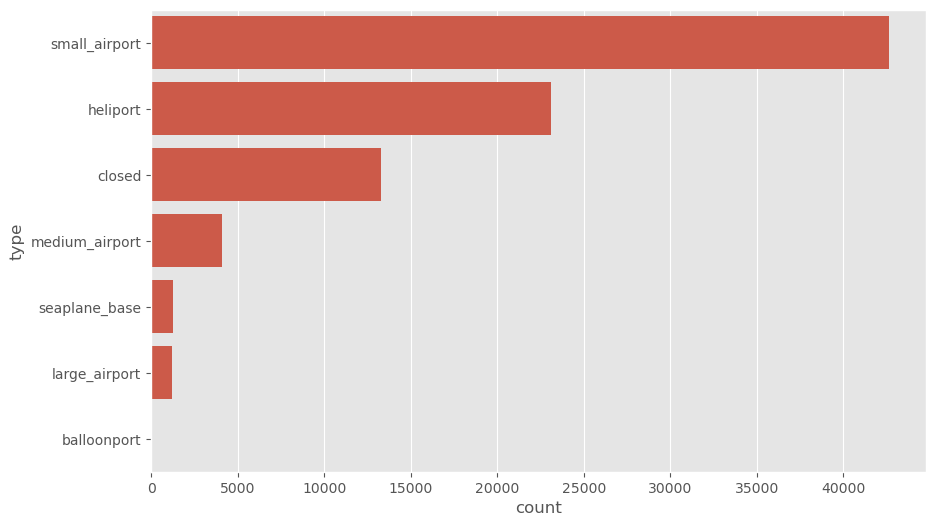

In [17]:
plt.figure(figsize=(10,6))

sns.countplot(
    y="type",
    data=airports,
    order=airports["type"].value_counts().index
)

plt.show()

In [18]:
airports["continent"].value_counts()

continent
AS    12730
EU    12513
SA    12279
AF     4231
OC     4221
AN       47
Name: count, dtype: int64

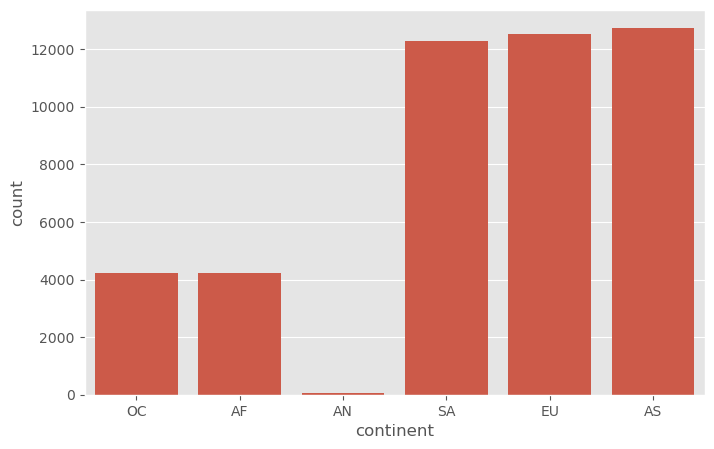

In [19]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="continent",
    data=airports
)

plt.show()

In [20]:
airports["iso_country"].value_counts().head(20)

iso_country
US    32567
BR     7964
JP     3747
CA     3331
AU     2789
MX     2694
RU     1808
FR     1774
GB     1604
DE     1434
KR     1422
IT     1116
AR      995
VE      898
PH      859
CN      776
CO      737
ID      728
ZA      674
IN      649
Name: count, dtype: int64

In [21]:
airports["municipality"].value_counts().head(20)

municipality
Osaka             420
Seoul             416
São Paulo         279
Los Angeles       246
Houston           152
Yokohama          147
Corumbá           143
Busan             137
Minato, Tokyo     126
Chiyoda, Tokyo    100
Nagoya             90
Rio de Janeiro     80
Itaituba           80
Kobe               77
Wasilla            73
Makati             71
Koto, Tokyo        68
Miami              67
Santiago           66
Greenville         64
Name: count, dtype: int64

In [22]:
airports["scheduled_service"].value_counts()

scheduled_service
no     81267
yes     4403
Name: count, dtype: int64

In [23]:
airports["ident"].isnull().sum()

airports["iata_code"].isnull().sum()

airports["gps_code"].isnull().sum()

np.int64(41334)